# ⚽ World Cup Match Prediction & Simulation Using Gradient Boosting Models

This notebook builds a machine learning system to predict football match outcomes and simulate a full tournament using historical data and ensemble learning (XGBoost, LightGBM, CatBoost).

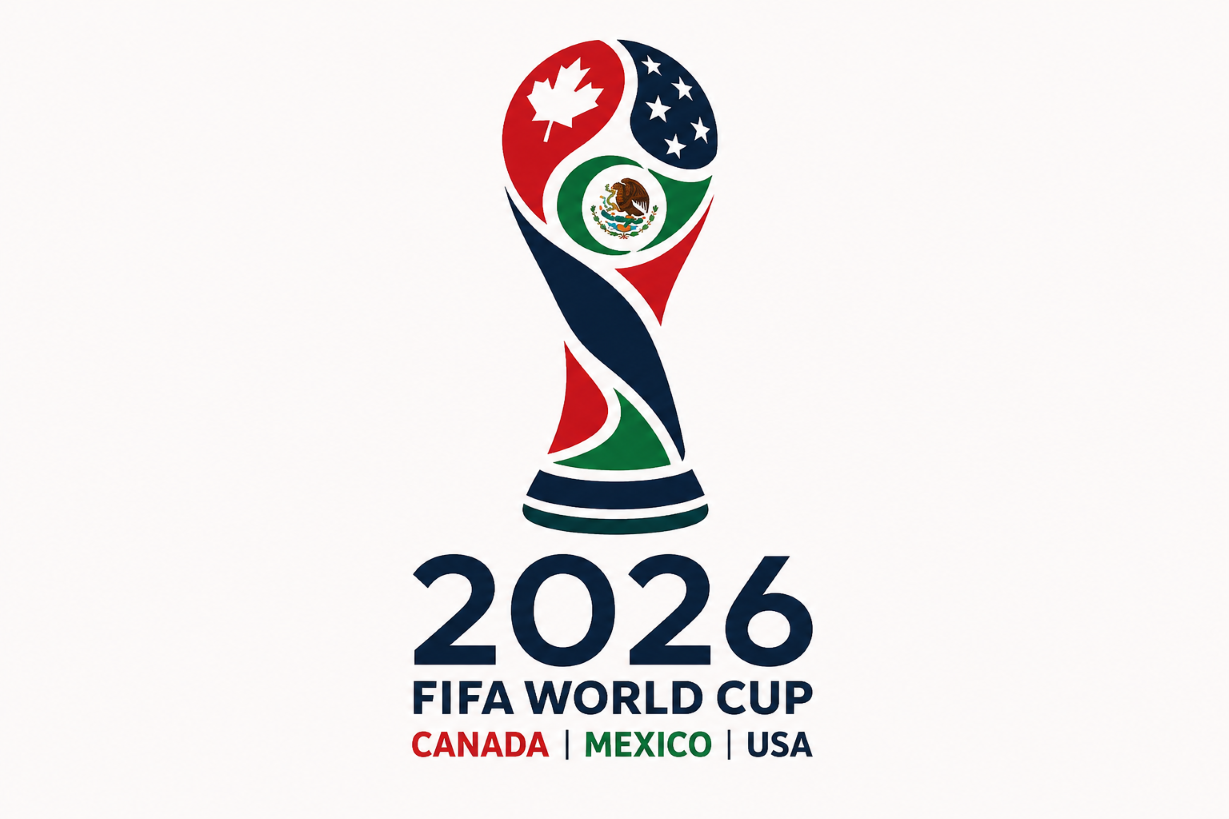

## 🎯 Objective

The goal of this project is to:

- Predict football match outcomes (or scores) using historical data
- Build strong regression models using gradient boosting techniques
- Improve accuracy using Time Series cross-validation
- Combine multiple models using weighted ensemble learning
- Simulate a full World Cup tournament based on predicted probabilities

## 📊 Dataset

The dataset contains approximately **18,000 football matches**, including:

- Team information
- Match statistics and features
- Temporal structure (time-based ordering)

The target variable represents match outcome (e.g., score difference / goals / result metric).

## 📊 Ensemble Model Performance (OOF Evaluation)

| Metric | Value |
|--------|------|
| MSE | **2.896** |
| MAE | **1.277** |
| R² Score | **0.346** |

### 🧠 Interpretation:

- The ensemble reduces variance compared to individual models  
- MAE indicates an average prediction error of ~1.28 units  
- R² shows the model explains ~34.6% of variance in the target variable

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
from src.country_normalizer import normalize_series
from src.elo import add_elo
from src.classify_tournaments import classify_tournament
from collections import defaultdict
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import minimize
from src.simulate_wc_2026 import run_monte_carlo
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [90]:
RANDOM_STATE= 8
N_SPLITS= 5
VERBOSE = True
EURO_TO_USD= 1.1
MAX_REST_DAY= 14
HOME_ADVANTAGE= 100
MATCH_TYPE_ORDER= {
    "f": 0,
    "q": 1,
    "t": 2,
    "w": 3
}

In [91]:
FIFA_RANKING_ADDR= "../data/fifa_ranking.csv"
SQUAD_STATS_ADDR= "../data/squad_stats.csv"
RESULT_ADDR= "../data/results.csv"

In [92]:
def rank_tier(rank):
    if rank <= 15:
        return 1
    elif rank <= 40:
        return 2
    elif rank <= 80:
        return 3
    else:
        return 4
def convert_to_usd(x, eur_to_usd):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    multiplier = 1
    if x.endswith("k"):
        multiplier = 1000
        x = x[:-1]
    elif x.endswith("m"):
        multiplier = 1_000_000
        x = x[:-1]
    if x.startswith("€"):
        value = float(x[1:])
        return value * multiplier*eur_to_usd
    if x.startswith("$"):
        value = float(x[1:])
        return value * multiplier
    return np.nan
def load_data():
    df= pd.read_csv(RESULT_ADDR)
    df["date"]= pd.to_datetime(df["date"])
    df= df.sort_values(by="date")
    df["year"]= df["date"].dt.year
    df= df[df["year"]>=1992]
    df= df.dropna(subset=["home_score", "away_score"])
    return df
def clean_team_name(df):
    df["home_team"] = normalize_series(df["home_team"])
    df = df[df["home_team"].notna()].copy()
    df["away_team"] = normalize_series(df["away_team"])
    df= df[df["away_team"].notna()].copy()
    return df
def merge_fifa_rank(df):
    rank_df= pd.read_csv(FIFA_RANKING_ADDR)
    rank_df= rank_df.sort_values("year")
    rank_df= rank_df.drop_duplicates(subset=["team", "year"], keep="first")
    rank_df= rank_df[["team", "year", "rank", "points"]]
    
    rank_df["team"]= normalize_series(rank_df["team"])
    rank_df= rank_df[rank_df["team"].notna()].copy()
    home_rank= rank_df.rename(columns={"team": "home_team", "rank": "home_rank", "points": "home_fifa_points"})
    df= df.merge(home_rank, on=["year", "home_team"], how="left")
    away_rank= rank_df.rename(columns={"team": "away_team", "rank": "away_rank", "points": "away_fifa_points"})
    
    df= df.merge(
        away_rank,
        on=["year", "away_team"],
        how="left"
    )
    df= df.dropna(subset=["home_rank", "away_rank"])
    return df
def merge_tm(df):    
    tm_df= pd.read_csv(SQUAD_STATS_ADDR)
    tm_df["team"]= normalize_series(tm_df["team"])
    tm_df= tm_df[tm_df["team"].notna()].copy()
    tm_df= tm_df.drop(columns="team_id")
    
    tm_df = tm_df.sort_values(["team", "year"])
    tm_df["avg_age"]= (tm_df.groupby("team")["avg_age"].transform(lambda x: x.interpolate()))
    tm_df["avg_age"]= (tm_df.groupby("team")["avg_age"].transform(lambda x: x.ffill()))
    tm_df["avg_market_value"]= tm_df["avg_market_value"].apply(lambda v: convert_to_usd(v, EURO_TO_USD))
    tm_df["avg_market_value"]= (tm_df.groupby("team")["avg_market_value"].transform(lambda x: x.ffill()))

    home_tm_df= tm_df.rename(columns={"team": "home_team", "avg_age": "home_avg_age", "avg_market_value": "home_avg_value"})
    df= df.merge(home_tm_df, on=["year", "home_team"], how="left")
    
    away_tm_df= tm_df.rename(columns={"team": "away_team", "avg_age": "away_avg_age", "avg_market_value": "away_avg_value"})
    df= df.merge(away_tm_df, on=["year", "away_team"], how="left")
    return df
def merge_external_df(df):
    df= merge_fifa_rank(df)
    df= merge_tm(df)
    return df
def handle_missing_value(df):
    df["away_score"]= df["away_score"].astype(int)
    df["home_score"]= df["home_score"].astype(int)
    df["gd"]= df["gd"].astype(int)
    return df

## ⚙️ Advanced Feature Engineering

We construct a set of engineered features to better capture team strength, match context, and historical interactions beyond raw statistics.

### 🧠 Core Strength Indicators
We include multiple measures of relative team quality such as:
- Elo rating differences and Elo-based win probability (including home advantage adjustment)
- FIFA points difference
- Ranking-based features (rank ratio and tier difference)

### 📊 Form and Squad Characteristics
To capture recent performance and squad quality, we compute:
- Recent win rate and goal difference trends (last 5 matches)
- Squad value and average age differences between teams

### 🏟️ Head-to-Head Dynamics
We model historical interactions between teams using:
- Recent head-to-head win rate and goal difference
- Total number of past encounters
- Indicator for first-ever meeting

### ⏱️ Contextual Factors
We include match context features such as:
- Days of rest for both teams before the match
- Difference in rest time (fatigue effect)

Missing historical values are handled using neutral defaults to avoid bias in unseen matchups.

In [93]:
def add_rank(df):
    df["home_rank_tier"]= df["home_rank"].apply(rank_tier)
    df["away_rank_tier"]= df["away_rank"].apply(rank_tier)
    df["home_rank"]= df["home_rank"].astype("Int64")
    df["away_rank"]= df["away_rank"].astype("Int64")
    df["rank_diff"]= df["away_rank"]-df["home_rank"]
    return df
def add_winrate(df):
    home_df= df[["date", "home_team", "home_res", "gd"]].copy()
    home_df.columns= ["date", "team", "res", "sd"]
    
    away_df= df[["date", "away_team", "home_res", "gd"]].copy()
    away_df.columns= ["date", "team", "res", "sd"]
    
    away_df["res"]= 1-away_df["res"]
    away_df["sd"]= -away_df["sd"]
    
    team_df= pd.concat([home_df, away_df])
    team_df= team_df.sort_values(["team", "date"])
    
    team_df["last5_winrate"]= (
        team_df.groupby("team")["res"]
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )
    team_df["last5_avg_sd"]= (
        team_df.groupby("team")["sd"]
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )
    teams_features= team_df[["date", "team", "last5_winrate", "last5_avg_sd"]]
    df= df.merge(
        teams_features,
        left_on=["date", "home_team"],
        right_on=["date", "team"],
        how="left"
    )
    df= df.rename(columns={
        "last5_winrate": "home_last5_winrate",
        "last5_avg_sd": "home_last5_avg_sd"
    })
    df= df.drop(columns=["team"])
    
    df= df.merge(
        teams_features,
        left_on=["date", "away_team"],
        right_on=["date", "team"],
        how="left"
    )
    df= df.rename(columns={
        "last5_winrate": "away_last5_winrate",
        "last5_avg_sd": "away_last5_avg_sd"
    })
    df= df.drop(columns=["team"])
    
    df["home_last5_winrate"]= df["home_last5_winrate"].fillna(0.5)
    df["away_last5_winrate"]= df["away_last5_winrate"].fillna(0.5)
    df["home_last5_avg_sd"]= df["home_last5_avg_sd"].fillna(0)
    df["away_last5_avg_sd"]= df["away_last5_avg_sd"].fillna(0)
    return df
def add_basic_features(df):
    df["gd"]= (df["home_score"]-df["away_score"])
    df["home_res"] = np.where((df["gd"]>0), 1, np.where(df["gd"]==0, 0.5, 0))
    df= add_rank(df)
    df= add_winrate(df)
    df["match_type"]= df["tournament"].map(classify_tournament)
    df["match_type_ordinal"]= df["match_type"].map(MATCH_TYPE_ORDER).astype(int)
    df["is_friendly"]= (df["match_type"] == "f").astype(int)
    return df
def add_advanced_features(df):
    df = df.copy()
    df["elo_diff"]= df["elo_home_pre"]-df["elo_away_pre"]
 
    elo_home_eff = df["elo_home_pre"]+df["neutral"].apply(lambda n: 0 if n else HOME_ADVANTAGE)
    df["elo_win_prob"]= 1/(1+ 10**((df["elo_away_pre"]-elo_home_eff)/400.0))
    df["fifa_points_diff"]= df["home_fifa_points"]-df["away_fifa_points"]
    df["rank_ratio"]= df["away_rank"]/df["home_rank"]
    df["tier_diff"] = df["away_rank_tier"] - df["home_rank_tier"]
    df["winrate_diff"]= df["home_last5_winrate"]-df["away_last5_winrate"]
    df["avg_sd_diff"]= df["home_last5_avg_sd"]-df["away_last5_avg_sd"]
    df["value_diff"]= df["home_avg_value"]-df["away_avg_value"]
    df["value_ratio"]= df["home_avg_value"]/df["away_avg_value"].replace(0, np.nan)
    df["age_diff"]= df["home_avg_age"]-df["away_avg_age"]

    h2h_history: dict[tuple, list]= defaultdict(list)
    last_match_date: dict[str, pd.Timestamp] = {}
    h2h_home_winrate= []
    h2h_avg_sd= []
    h2h_total= []
    home_days_rest= []
    away_days_rest= []
 
    for row in df.itertuples(index=False):
        home= row.home_team
        away= row.away_team
        date= row.date

        key= tuple(sorted([home, away]))
        past= h2h_history[key]
        is_home_key = (home == key[0])
        if len(past)==0:
            h2h_home_winrate.append(np.nan)
            h2h_avg_sd.append(np.nan)
            h2h_total.append(0)
        elif len(past)<5:
            last5= past[-len(past):]
            wins= sum((1 if sd>0 else 0) for sd in last5) if is_home_key else sum((1 if sd<0 else 0) for sd in last5)
            h2h_home_winrate.append(wins/len(last5))
            raw_avg = np.mean(last5)
            h2h_avg_sd.append(raw_avg if is_home_key else -raw_avg)
            h2h_total.append(len(past))
        else:
            last5= past[-5:]
            wins= sum((1 if sd>0 else 0) for sd in last5) if is_home_key else sum((1 if sd<0 else 0) for sd in last5)
            h2h_home_winrate.append(wins/len(last5))
            raw_avg = np.mean(last5)
            h2h_avg_sd.append(raw_avg if is_home_key else -raw_avg)
            h2h_total.append(len(past))
 
        if home in last_match_date:
            home_days_rest.append(min(MAX_REST_DAY, (date-last_match_date[home]).days))
        else:
            home_days_rest.append(MAX_REST_DAY)
 
        if away in last_match_date:
            away_days_rest.append(min(MAX_REST_DAY, (date-last_match_date[away]).days))
        else:
            away_days_rest.append(MAX_REST_DAY)
            
        sd= row.gd
        if key[0]==home:
            h2h_history[key].append(sd)
        else:
            h2h_history[key].append(-sd)
 
        last_match_date[home]= date
        last_match_date[away]= date
 
    df["h2h_last5_home_winrate"]= h2h_home_winrate
    df["h2h_last5_avg_gd"]= h2h_avg_sd
    df["h2h_total_matches"]= h2h_total
    df["h2h_is_first_meeting"]= (df["h2h_total_matches"]== 0).astype(int)
    df["home_days_rest"]= home_days_rest
    df["away_days_rest"]= away_days_rest
    df["rest_diff"]= df["home_days_rest"]-df["away_days_rest"]
    
    df["h2h_last5_home_winrate"]= df["h2h_last5_home_winrate"].fillna(0.5)
    df["h2h_last5_avg_gd"]= df["h2h_last5_avg_gd"].fillna(0.0)
 
    return df

In [94]:
df= load_data()
df= clean_team_name(df)
df= merge_external_df(df)
df= add_basic_features(df)
df= add_elo(df)
df= add_advanced_features(df)
df= handle_missing_value(df)

In [95]:
metadata_cols= [
    "date", "home_team", "away_team", "city", "country", 
    "tournament", "match_type", "home_res", "home_score", 
    "away_score", "year", "gd"
]

clean_df= df[df["year"]>2003].dropna()
X= clean_df.drop(columns=metadata_cols)
y= clean_df["gd"]
tscv= TimeSeriesSplit(n_splits=N_SPLITS)

## ⚙️ Methodology

This project follows a structured machine learning pipeline designed specifically for **time-series aware football match prediction** and robust ensemble learning.

---

### 🤖 Models

We use a combination of powerful gradient boosting models:

- **XGBoost Regressor:**  strong performance on structured/tabular data with regularization control  
- **LightGBM Regressor:**  highly efficient gradient boosting optimized for speed and large feature spaces  
- **CatBoost Regressor:**  robust handling of categorical-like patterns and reduced preprocessing needs  

Each model captures different aspects of the data distribution, improving diversity in the final ensemble.

---

### 🔧 Hyperparameter Optimization

Model hyperparameters are tuned using:

- **GridSearchCV**
- Reduced and carefully selected parameter ranges for computational efficiency
- TimeSeriesSplit used consistently within the tuning process

This allows a balance between:
- computational cost ⚡  
- model performance 🎯  
- stability across folds 📈  

---

### ⚖️ Ensemble Strategy

To improve predictive accuracy and robustness, we combine all models using an ensemble approach:

- Out-of-fold (OOF) predictions are generated for each base model
- A weighted linear combination is applied
- Final weights are optimized by minimizing **Mean Squared Error (MSE)**

This approach reduces variance and leverages the complementary strengths of each model.

In [96]:
oof_xgb= np.zeros(len(X))
oof_lgb= np.zeros(len(X))
oof_cat= np.zeros(len(X))

cv_scores= {"xgb": [], "lgb": [], "cat": []}

In [97]:
xgb_param_grid = {
    "n_estimators": [400, 600],
    "max_depth": [4, 6],
    "learning_rate": [0.05],
    "subsample": [0.85],
    "colsample_bytree": [0.8],
    "min_child_weight": [1],
    "gamma": [0.0],
}

lgb_param_grid = {
    "n_estimators": [400],
    "num_leaves": [31, 63],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.85],
    "min_child_samples": [10],
}

cat_param_grid = {
    "depth": [4, 6],
    "learning_rate": [0.03, 0.05],
    "iterations": [400, 600],
}

In [98]:
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

lgb_grid = GridSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=lgb_param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=0
)

cat_grid = GridSearchCV(
    CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
    param_grid=cat_param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

xgb_grid.fit(X, y)
lgb_grid.fit(X, y)
cat_grid.fit(X, y)

best_xgb= xgb_grid.best_estimator_
best_lgb= lgb_grid.best_estimator_
best_cat= cat_grid.best_estimator_

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001701 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4768
[LightGBM] [Info] Number of data points in the train set: 18839, number of used features: 37
[LightGBM] [Info] Start training from score 0.486650


## 📈 Model Performance (Cross-Validation)

| Model | CV MSE | RMSE | 
|------|--------|-------|
| XGBoost | 2.7708 | 1.664574
| LightGBM | 2.7786 | 1.666924
| CatBoost | 2.6912 | 1.640489

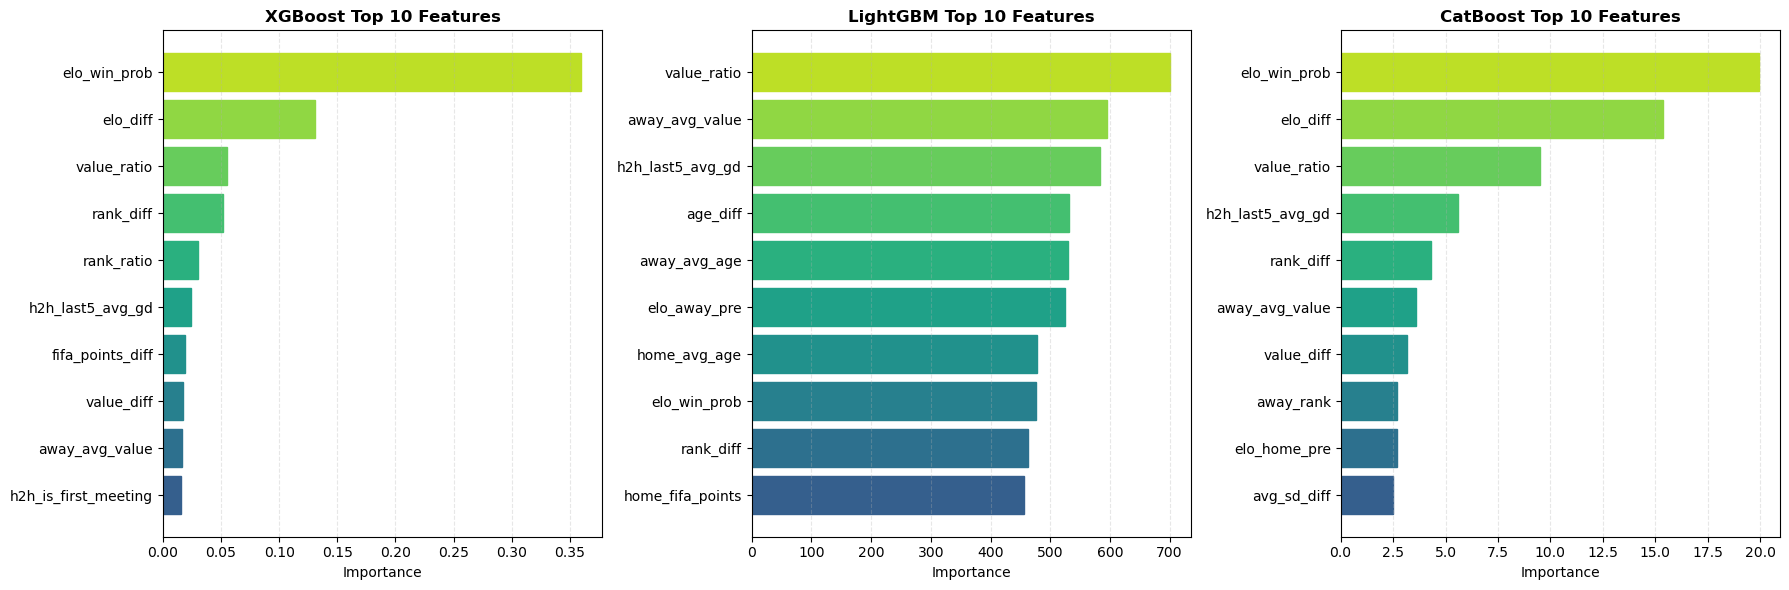

In [99]:
def plot_feature_importance(model, X, title, ax):
    importances= model.get_feature_importance() if hasattr(model, "get_feature_importance") else model.feature_importances_
    feat_imp= pd.DataFrame({"feature": X.columns, "importance": importances})

    top10= feat_imp.sort_values("importance", ascending=False).head(10)
    top10= top10.iloc[::-1]

    bars = ax.barh(top10["feature"], top10["importance"])
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top10)))
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Importance")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_feature_importance(best_xgb, X, "XGBoost Top 10 Features", axes[0])
plot_feature_importance(best_lgb, X, "LightGBM Top 10 Features", axes[1])
plot_feature_importance(best_cat, X, "CatBoost Top 10 Features", axes[2])

plt.tight_layout()
plt.show()

In [ ]:
cv_scores= {"xgb": [], "lgb": [], "cat": []}

fold= 1
for train_idx, val_idx in tscv.split(X):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    xgb_model = best_xgb
    xgb_model.fit(X_train, y_train)
    pred_xgb = xgb_model.predict(X_val)

    oof_xgb[val_idx] = pred_xgb
    mse_xgb = mean_squared_error(y_val, pred_xgb)
    cv_scores["xgb"].append(mse_xgb)

    lgb_model = best_lgb
    lgb_model.fit(X_train, y_train)
    pred_lgb = lgb_model.predict(X_val)

    oof_lgb[val_idx] = pred_lgb
    mse_lgb = mean_squared_error(y_val, pred_lgb)
    cv_scores["lgb"].append(mse_lgb)

    cat_model = best_cat
    cat_model.fit(X_train, y_train)
    pred_cat = cat_model.predict(X_val)

    oof_cat[val_idx] = pred_cat
    mse_cat = mean_squared_error(y_val, pred_cat)
    cv_scores["cat"].append(mse_cat)
    fold += 1
y_oof= y
oof_xgb_= oof_xgb
oof_lgb_= oof_lgb
oof_cat_= oof_cat

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000815 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4320
[LightGBM] [Info] Number of data points in the train set: 3144, number of used features: 37
[LightGBM] [Info] Start training from score 0.492048
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001161 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4561
[LightGBM] [Info] Number of data points in the train set: 6283, number of used features: 37
[LightGBM] [Info] Start training from score 0.490371
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001085 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4636
[LightGBM] [Info] Number of data points in the train set: 9422, number of used features: 37
[LightGBM] [Info] Start traini

In [101]:
from scipy.optimize import minimize
import numpy as np
from sklearn.metrics import mean_squared_error

def ensemble_mse(weights):
    w = np.abs(weights) / (np.sum(np.abs(weights)) + 1e-9)
    preds= (w[0]*oof_xgb_+ w[1]*oof_lgb_+w[2]*oof_cat_)
    return mean_squared_error(y_oof, preds)

initial_weights = np.array([1.0, 1.0, 1.0])

res = minimize(ensemble_mse, initial_weights, method="Nelder-Mead", options={"maxiter": 5000})
best_weights = np.abs(res.x) / np.sum(np.abs(res.x))

In [102]:
ensemble_oof_valid= best_weights[0]*oof_xgb_ + best_weights[1]*oof_lgb_ + best_weights[2]*oof_cat_
ensemble_mse_val= mean_squared_error(y_oof, ensemble_oof_valid)
ensemble_mae_val= mean_absolute_error(y_oof, ensemble_oof_valid)
ensemble_r2_val= r2_score(y_oof, ensemble_oof_valid)

## 🏆 World Cup Simulation

Using the trained ensemble model, we simulate match outcomes:

- Each match is predicted using ensemble output
- Probabilities determine win/draw/loss outcomes
- Tournament progresses from group stage to knockout rounds and final

In [103]:
home_df= clean_df[["date", "home_team", "home_res", "gd"]].copy()
away_df= clean_df[["date", "away_team", "home_res", "gd"]].copy()
away_df.columns= ["date", "team", "res", "sd"]
home_df.columns= ["date", "team", "res", "sd"]   
away_df["res"]= 1-away_df["res"]
away_df["sd"]= -away_df["sd"]

team_df= pd.concat([home_df, away_df])
team_df= team_df.sort_values(["team", "date"])
    
team_df["rolling_winrate"] = (
    team_df.groupby("team")["res"]
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

team_df["rolling_avg_sd"] = (
    team_df.groupby("team")["sd"]
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)
team_df= team_df.drop(columns=["sd", "res"])

clean_df = clean_df.merge(
    team_df, 
    left_on=["date", "home_team"], 
    right_on=["date", "team"], 
    how="left"
).rename(columns={"rolling_winrate": "home_post_last5_winrate", "rolling_avg_sd": "home_post_last5_avg_sd"}).drop(columns=["team"])
clean_df = clean_df.merge(
    team_df, 
    left_on=["date", "away_team"], 
    right_on=["date", "team"], 
    how="left"
).rename(columns={"rolling_winrate": "away_post_last5_winrate", "rolling_avg_sd": "away_post_last5_avg_sd"}).drop(columns=["team"])

In [104]:
def build_h2h_history(clean_df):
    h2h = defaultdict(lambda: defaultdict(list))

    for row in clean_df.itertuples(index=False):
        home = row.home_team
        away = row.away_team
        gd= row.gd

        h2h[home][away].append(gd)
        h2h[away][home].append(-gd)
    return h2h
def compute_h2h_features(home, away, h2h_history):
    matches = h2h_history[home][away]

    total= len(matches)
    is_first= 1 if total == 0 else 0

    if is_first:
        return {
            "h2h_last5_home_winrate":0.5,
            "h2h_last5_avg_gd":0,
            "h2h_total_matches": 0,
            "h2h_is_first_meeting": 1,
        }

    last5 = matches[-5:]
    gd_sum= sum(last5)
    wins = sum(1 for gd in last5 if gd > 0)

    return {
        "h2h_last5_home_winrate": wins/len(last5),
        "h2h_last5_avg_gd": gd_sum / len(last5),
        "h2h_total_matches": total,
        "h2h_is_first_meeting": is_first
    }

In [105]:
team_features = {}
clean_df= clean_df.sort_values("date")
for team in pd.concat([clean_df["home_team"], clean_df["away_team"]]).unique():
    home_rows = clean_df[clean_df["home_team"] == team]
    away_rows = clean_df[clean_df["away_team"] == team]

    last_home = home_rows.iloc[-1] if len(home_rows) > 0 else None
    last_away = away_rows.iloc[-1] if len(away_rows) > 0 else None

    if last_home is not None and last_away is not None:
        row_is_home = last_home["date"] >= last_away["date"]
    elif last_home is not None:
        row_is_home = True
    else:
        row_is_home = False

    if row_is_home:
        row = last_home
        team_features[team] = {
            "elo":           row["elo_home_pre"],
            "rank":          row["home_rank"],
            "fifa_points":   row["home_fifa_points"],
            "rank_tier":     row["home_rank_tier"],
            "last5_winrate": row["home_post_last5_winrate"],
            "last5_avg_sd":  row["home_post_last5_avg_sd"],
            "avg_age":       row["home_avg_age"],
            "avg_value":     row["home_avg_value"],
            "last_match_date": row["date"]
        }
    else:
        row = last_away
        team_features[team] = {
            "elo":           row["elo_away_pre"],
            "rank":          row["away_rank"],
            "fifa_points":   row["away_fifa_points"],
            "rank_tier":     row["away_rank_tier"],
            "last5_winrate": row["away_post_last5_winrate"],
            "last5_avg_sd":  row["away_post_last5_avg_sd"],
            "avg_age":       row["away_avg_age"],
            "avg_value":     row["away_avg_value"],
            "last_match_date": row["date"]
        }

## 🏆 World Cup Monte Carlo Simulation Insights

The simulation results provide a full probability landscape across all tournament stages.

### 📊 Key Observations:

- A small number of teams dominate championship probability
- Many teams have high group-stage survival but low knockout conversion
- Strong correlation between quarter-final and championship probability
- Clear separation between elite tier and mid-tier teams

### ⚽ Key Insight:

Tournament success is highly non-linear — early-stage strength does not guarantee final victory.

In [106]:
mf_columns= ["home_team", "away_team", "gd", "date"]
h2h_history= build_h2h_history(clean_df)
results = run_monte_carlo(
    model_ensemble=(best_xgb, best_lgb, best_cat),
    weights=best_weights,
    clean_df= clean_df.copy(),
    team_features=team_features,
    h2h_history= h2h_history,
    n_simulations=10000
)

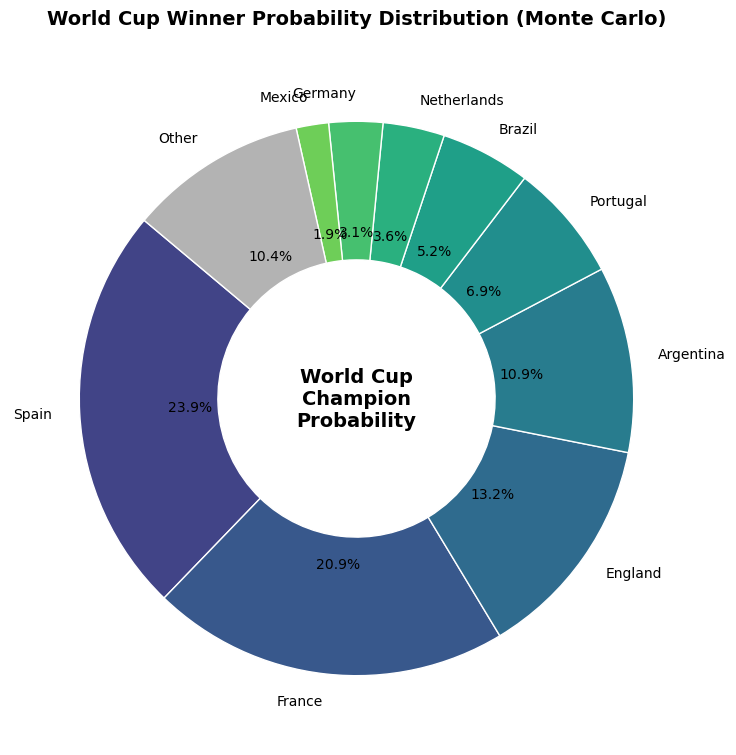

In [116]:
top = results.sort_values("champion%", ascending=False).head(9)
other_sum = results.sort_values("champion%", ascending=False).iloc[9:]["champion%"].sum()

labels = list(top["team"]) + ["Other"]
values = list(top["champion%"]) + [other_sum]
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(labels)))
colors[-1]= (0.7, 0.7, 0.7, 1.0) 

plt.figure(figsize=(9,9))

wedges, texts, autotexts = plt.pie(
    values,
    labels=labels,
    autopct=lambda p: f"{p:.1f}%",
    startangle=140,
    colors=colors,
    wedgeprops={
        "width": 0.5, 
        "edgecolor": "white",
        "linewidth": 1
    },
    textprops={"fontsize": 10}
)

plt.text(
    0, 0,
    "World Cup\nChampion\nProbability",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

plt.title("World Cup Winner Probability Distribution (Monte Carlo)", 
          fontsize=14, fontweight="bold", pad=20)

plt.show()

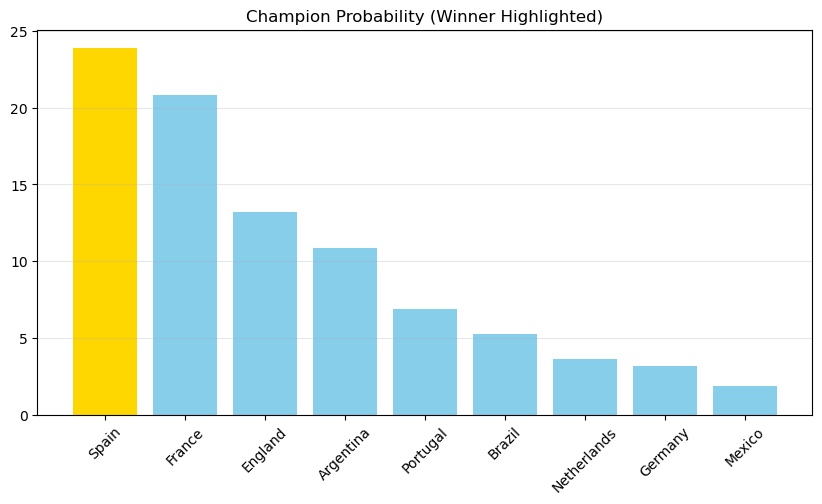

In [113]:
colors = ["gold" if i == top.iloc[0]["team"] else "skyblue" for i in top["team"]]

plt.figure(figsize=(10,5))
plt.bar(top["team"], top["champion%"], color=colors)

plt.title("Champion Probability (Winner Highlighted)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

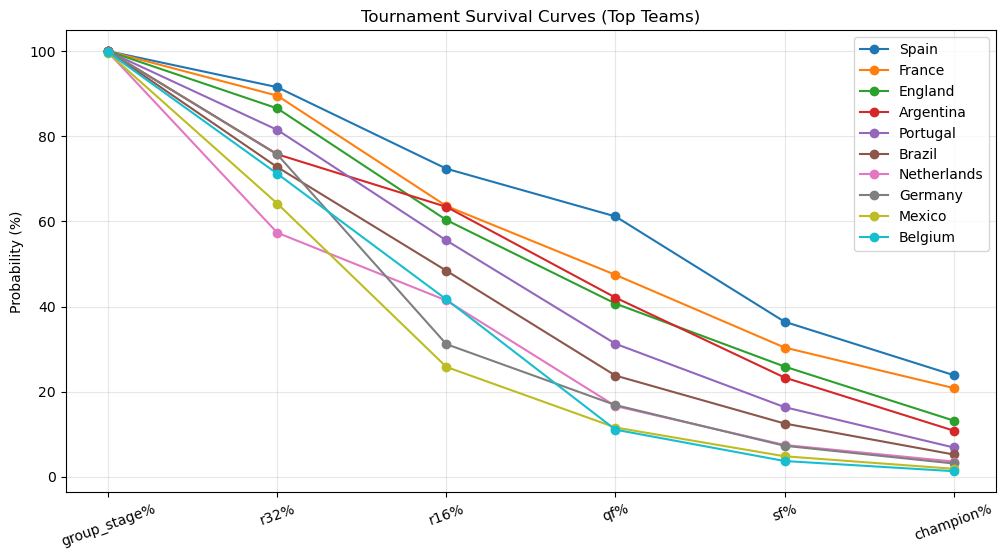

In [114]:
stages = ["group_stage%", "r32%", "r16%", "qf%", "sf%", "champion%"]

plt.figure(figsize=(12,6))

for i, row in results.sort_values("champion%", ascending=False).head(10).iterrows():
    plt.plot(stages, row[stages], marker="o", label=row["team"])

plt.title("Tournament Survival Curves (Top Teams)")
plt.ylabel("Probability (%)")
plt.xticks(rotation=20)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

c:\Users\alireza\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


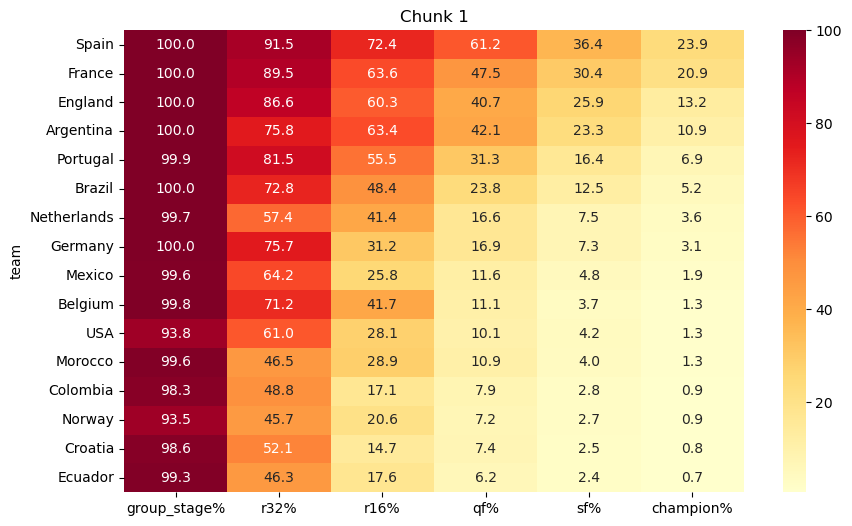

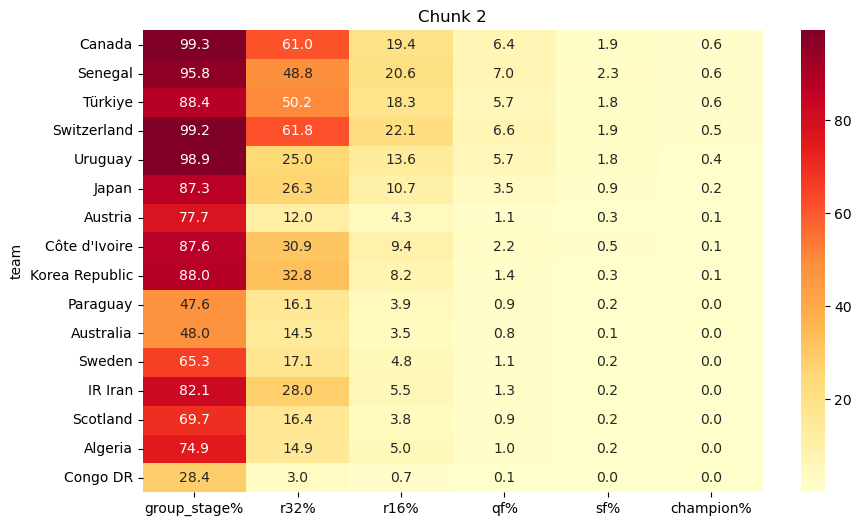

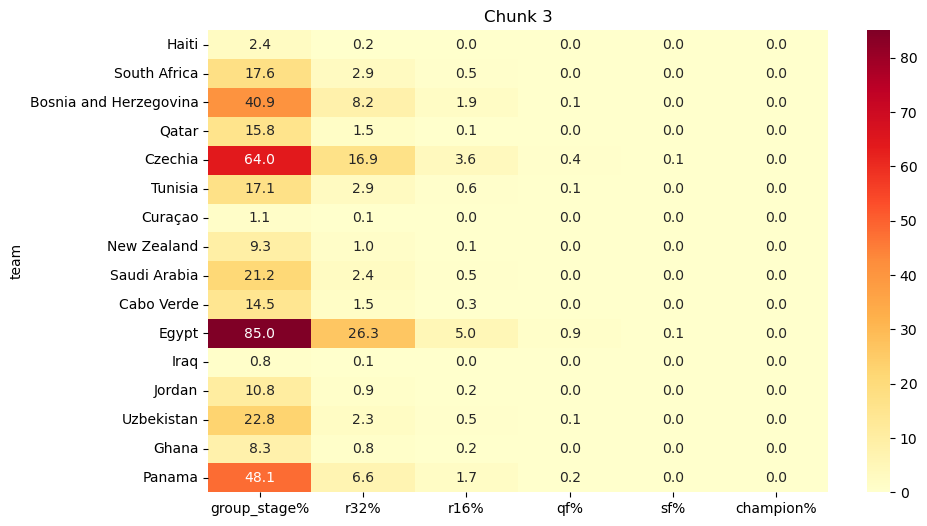

In [ ]:
heatmap_data = results.set_index("team")[stages]
chunks = np.array_split(heatmap_data, 3)

for i, chunk in enumerate(chunks):
    plt.figure(figsize=(10, 6))
    sns.heatmap(chunk, annot=True, fmt=".1f", cmap="YlOrRd")
    plt.title(f"Chunk {i+1}")
    plt.show()

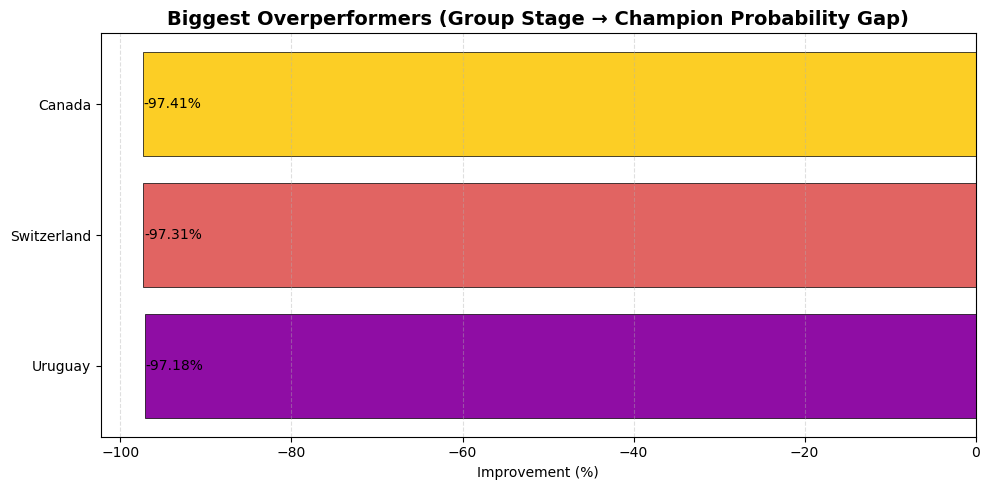

In [111]:
results["improvement"] = results["sf%"] - results["group_stage%"]

top_improvers = results.sort_values("improvement", ascending=True).head(3)
top_improvers = top_improvers.iloc[::-1]

plt.figure(figsize=(10,5))
colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(top_improvers)))

bars = plt.barh(
    top_improvers["team"],
    top_improvers["improvement"],
    color=colors,
    edgecolor="black",
    linewidth=0.5
)

for bar in bars:
    plt.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}%",
        va="center",
        fontsize=10
    )

plt.title("Biggest Overperformers (Group Stage → Champion Probability Gap)",
          fontsize=14, fontweight="bold")

plt.xlabel("Improvement (%)")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 📊 Key Insights

- Ensemble models outperform individual models
- Gradient boosting models capture nonlinear team interactions effectively
- Time-series validation is crucial to avoid overfitting
- Model performance is sensitive to feature engineering and temporal structure

## ⚠️ Limitations

- No injury or lineup information included
- External factors (weather, home advantage dynamics) simplified
- Simulation assumes independence between matches
- Historical bias in data may affect predictions

## 🚀 Conclusion

This project demonstrates how machine learning models can be used to simulate football tournaments realistically.

By combining multiple gradient boosting models and optimizing ensemble weights, we achieve a robust prediction system suitable for match outcome forecasting.